Detecção de fraudes em transações bancárias

In [1]:
# importando o dataset de API, disponível utilizada para exercício.
# variável class é a mais importante, em que 0 a transacao não é fraudulenta, e 1 indica fraude.
# preparar para começar a analisar padrões de comportamento.
import pandas as pd
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Problema de classificação desbalanceada

In [2]:
# Um dos pontos mais importantes da detecção de fraude
# Calculando a proporção de cada tipo de transação
# Interpretação = dataset desbalanceado, tem mais de um tipo de fraude do que a outra
# Pode ensinar o modelo a aprender errado --> acaba levando a baixa acurácia
# para que o modelo não seja inútil --> quero que ele acerte a classe rara (fraude), pois é a mais perigosa caso não seja detectada.
df["Class"].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


Feature engineering

In [3]:
# Podemos criar novas variaveis que nos ajudem a interpretar melhor com o modelo, transformar os dados brutos em informações úteis para o modelo
# É necessário porque o modelo não aprende o contexto
# Foi usado transformação logarítmica, que é para comprimir valores = valores muito grandes diminuem em escala, valores pequenos são menos afetados
# Para evitar problemas com valores iguais a zero, pois em dados financeiros é normal ter valores muito discrepantes e atrapalhar o aprendizado do modelo
import numpy as np
df["Amount_log"] = np.log1p(df["Amount"])

In [4]:
# Padronização dos dados
# Valores diferentes ficam na mesma escala, independente do tamanho original, passando a ser comparáveis
# O fit vai calcular a média e o DP da coluna amount
# o Transform aplica a transformação aos valores e mostra na coluna amount scaled
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

In [5]:
# Preparar os dados para treinar o modelo
# Separo as variáveis em x e y
# x representa as features = todas as variáveis de entrada
# y represent o target = o que estamos buscando analisar se é fraude ou não
from sklearn.model_selection import train_test_split
x = df.drop("Class", axis=1)
y = df["Class"]

#separando os dados em conjuntos de teste e treino, porque o conjunto de treino é usado para ensinar o modelo, e o conjunto de teste é usado para avaliar o modelo depois
# test size = 0.3 significa que 70% dos dados foram usados para treinar o modelo e 30% dos dados foram usados para o teste posteriormente
# random_state = 42 serve para garantir que a divisão seja sempre a mesma, para melhor reprodutibilidade
# stratify=y garante que a proporção de fraudes e não fraudes seja mantida, tanto no treino quanto no teste, caso contrario poderia mostrar um conjunto de dados com pouca ou nenhuma fraude uma vez que o dataset é desbalanceado
x_train, x_test, y_train, y_test = train_test_split(
    x, y, stratify=y, test_size=0.3, random_state=42
)

Avaliação dos modelos/Modelagem de dados

Regressão logística

In [6]:
# O modelo de regressão logística é um modelo de classificação, objetivo é prever categorias, nesse caso, se é fraude (classe 0) ou não (classe 1)
# max_iter de 1000 são quantas iterações ele vai convergir
# modelo aprende padrões a partir dos dados de treino com o model.fit
# no modelo model.predict ele vai avaliar oss 30% de dados (dados do conjunto teste) para avaliar se tem fraude
# o aviso gerado é porque chegou no máximo de iterações permitido, o que pode ser resolvido aumentando a quantidade de iterações
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
# para ver as métricas mais importantes para as classificações --> avaliando como o modelo desempenhou
# foco na classe 1 porque é a classe que mostra as fraudes
# A precisão de 0.84 indica que entre todas as transações, o modelo identificou que 84% delas eram fraude.
# A recall de 0.66 indica que o modelo conseguiu identificar 66% das fraudes reais, o que precupa pois ele está deixando de detectar 34% das fraudes reais.
# o F1-score dá uma visão geral da qualidade do modelo, mostrando o equilíbrio entre acurácia e recall.
# o fato de o modelo ter um f1-score de 1 significa que ele ficou viciado, detectando todas as transacoes de classe 0, mas que não representa um bom resultado pra sua capacidade de detectar as fraudes.
# Por isso, é melhor olhar o recall do que o valor da acurácia, ou seja se as verdadeiras fraudes foram detectadas.
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.66      0.73       148

    accuracy                           1.00     85443
   macro avg       0.92      0.83      0.87     85443
weighted avg       1.00      1.00      1.00     85443



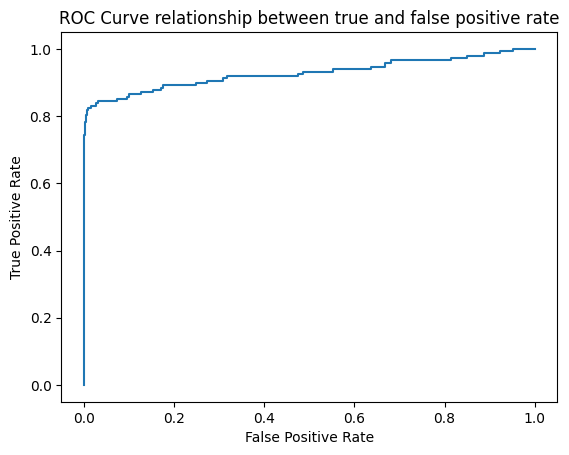

AUC: 0.9272042339543365


In [8]:
# Curva ROC mostra o desempenho do modelo em diferentes limiares de decisão
# True Positive Rate mostra o mesmo que o recall, ou o quantas fraudes o modelo conseguiu identificar
# False Positive Rate mostra quantas transações normais foram classificadas como fraude
# Cada ponto representa um limite diferente da decisão do modelo, para analisar o comportamento geral
# Quanto mais próximo do canto superior esquerdo, melhor o modelo = alto recall e baixo erro
# Se a curva for uma diagonal reta, o modelo seria aleatório, sem capacidade de distinguir fraude e não fraude.
# valor da área abaixo da curva (AUC) indica um valor proximo de 1 e um modelo muito bom, 0.5 seria um modelo aleatório.
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(x_test)[:,1]

fpr, tpr, _ =  roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve relationship between true and false positive rate")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()
print("AUC:", roc_auc_score(y_test, y_probs))

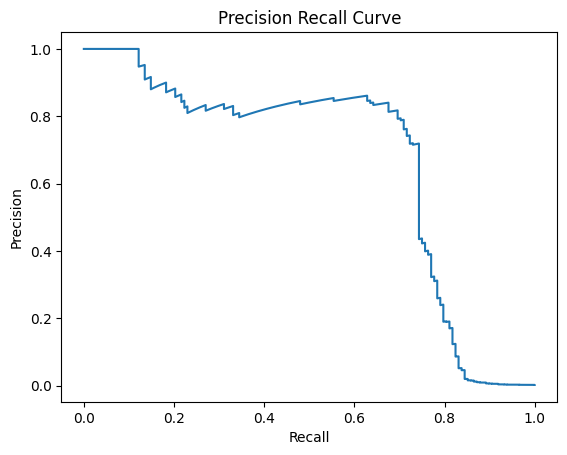

In [9]:
# Importante observar o tradeoff entre as duas métricas
# Quanto mais aumenta o recall, a precision diminui, e vice versa
# No início, o modelo é mais conservador porque a precision estava em 1, ou seja, só aponta fraude quanto tem muita certeza
# À medida que o recall aumenta, o modelo passa a identificar mais fraudes
# Porém, o precision cai, o que aumenta os falsos positivos
# No final, quando o recall está alto e a precision muito baixa, significa que o modelo está marcando muitas transações como fraude, incluindo as que não são
# Em problemas desbalanceados, mostra um melhor modelo do que a curva ROC por si só
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

Balanceamento de dados (Técnica Undersampling escolhida)

In [10]:
# Undersampling = Pegar todas as fraudes e utiliza a mesma quantidade de transações usando o sample
# Reduz a classe majoritária (classe 0) para ficar do mesmo tamanho da classe minoritária (classe 1)
# Risco é de perder muitos dados normais, perder a qualidade geral dos dados
fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0].sample(len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])

In [11]:
# Modelo baseado em árvores de decisão, tende a ser mais preciso do que a regressão logística
# Aqui, o modelo já consegue detectar 76% das fraudes, e o f1-score também aumentou, agora estando em 0.79
#
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs= -1,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



In [12]:
# Pipeline serve para organizar o fluxo de processamento em 2 etapas
# O standard scaler e a regressão logística, tudo em um único fluxo, o que diminui o risco de erros e garante mais consistência
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)

In [13]:
# Ajuste do limite para 0.3 (por padrão é 0.5) significa ter mais rigor com a fraude, ser capaz de detectar mais as fraudes
# Só com a regressão logística estava em 0.69, com o ajuste do threshold aumentou para 0.71.
threshold = 0.3

y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.79      0.71      0.75       148

    accuracy                           1.00     85443
   macro avg       0.89      0.85      0.87     85443
weighted avg       1.00      1.00      1.00     85443



Modelo Avançado - XGBoost

In [14]:
# Modelo mais avançado e baseado em boosting --> técnica de modelos simples, geralmente árvores, em que cada modelo tenta corrigir os modelos anteriores, garantindo um aprendizado sequencial
# Cada árvore utiliza do aprendizado da árvore anterior, diferente do randomforest em que as árvores são independentes
# Muito utilizado e mais poderoso, útil em aplicações reais, como para detectar fraudes
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:40:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [15]:
# A precision ficou em 0.93, ou seja, quando o modelo diz que é fraude, ele acertou em 93% dos casos
# O recall fiocu em 0.78, ou seja, em 78% das fraudes.
# O F1-score é 85%, um bom equilíbrio entre precision e recall.
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.93      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.96      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443



Importância das Variáveis

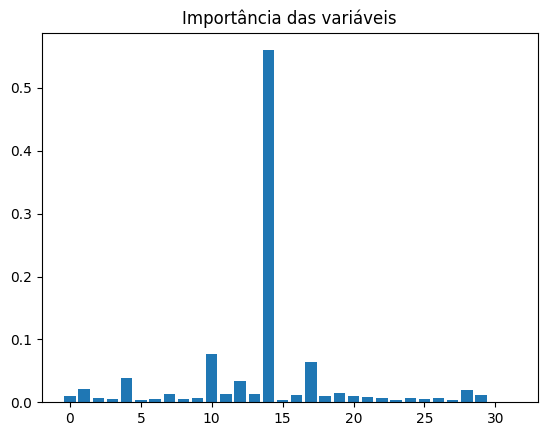

In [16]:
# No eixo horizontal, temos as variáveis de 1 a 28
# No eixo vertical, temos o peso de cada variável no modelo
# Algumas variáveis vão ter um peso maior que outras no padrão de aprendizagem do modelo
# Mesmo sendo um modelo complexo, ajuda a focar e selecionar as variáveis mais importantes
# Ajuda no entendimento do modelo do negócio, mostrando o que essa variável representa e como ela se relaciona com a fraude.
import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das variáveis")
plt.show()

Ajuste de hiperparêmetros

In [17]:
# Testa várias combinações de parâmetros automaticamente
# São parâmetros que não são aprendidos pelo modelo, mas que precisam ser definidos por nós
# O Grid vai testar todas as combinações possíveis entre esses fatores, e avaliar qual o melhor, nesse caso o melhor é o recall - por isso foi definido como o melhor abaixo.
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring="recall",
    cv=3
)

grid.fit(x_train, y_train)

print("Melhor modelo:", grid.best_params_)

Melhor modelo: {'max_depth': 3, 'n_estimators': 100}


Explicabilidade (SHAP)

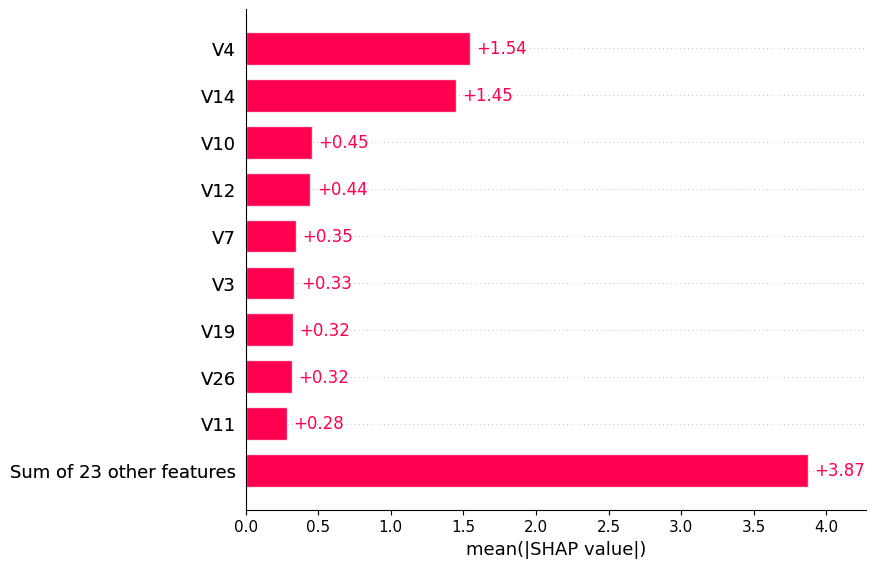

In [18]:
# SHAP é uma técnica que explica quanto cada variável vai impactar o modelo, por consequente, na decisão
# o mean shap value é a média de impacto de cada variável --> quanto maior o valor, mais essa variável vai impactar
# A V4 e a V14 são as duas variáveis que mais impactam, as mais importantes.
# Permite entender o modelo, mesmo em cenários complexos como no caso de fraudes --> importante para confiança, auditoria e tomada de decisão.
import shap
explainer = shap.Explainer(xgb)
shap_values = explainer(x_test[:100])

shap.plots.bar(shap_values)

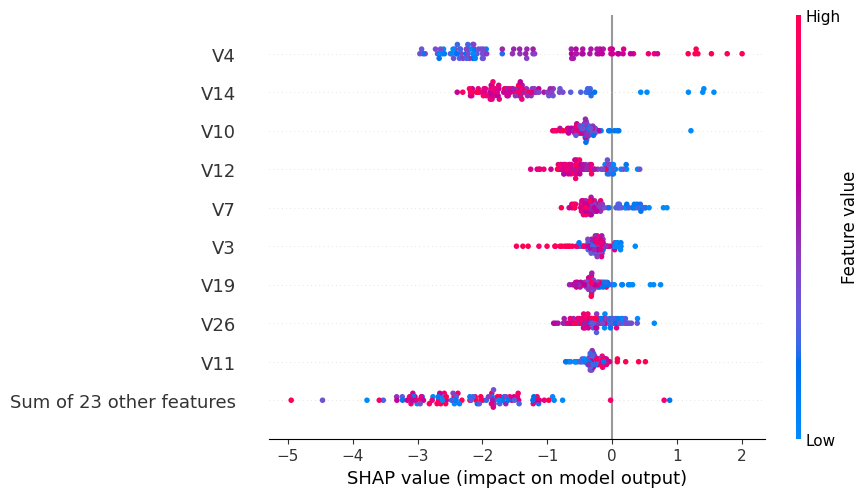

In [19]:
# outras formas de observar em gráficos diferentes do de barras mencionados em aula pela profa. Isadora
# as variáveis v4 e v14 continuam sendo visivelmente as que mais impactaram o modelo e sua tomada de decisão em detectar fraude
import shap
explainer = shap.Explainer(xgb)
shap_values = explainer(x_test[:100])

shap.plots.beeswarm(shap_values)

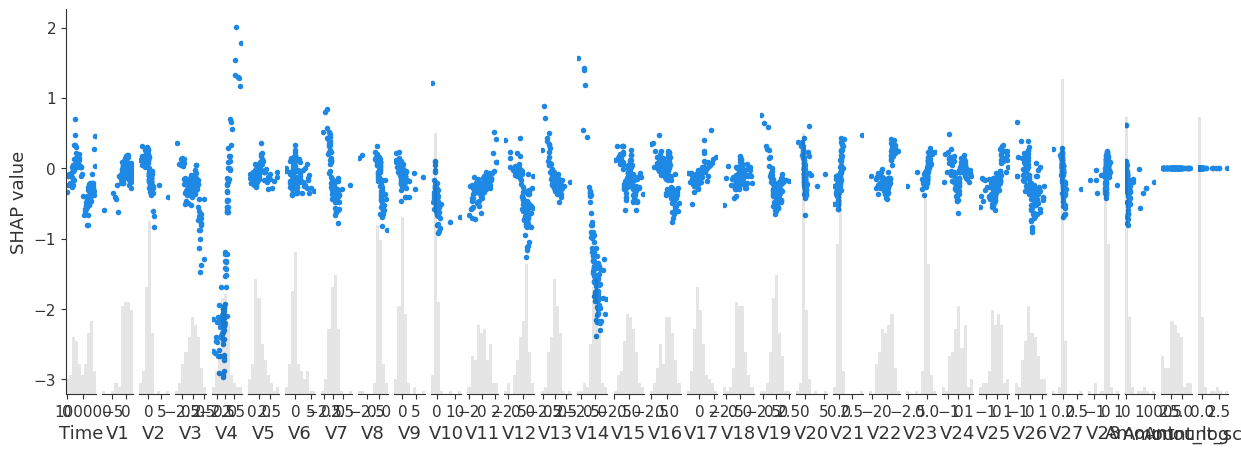

In [24]:
# outro modelo de gráfico com a técnica SHAP, ainda em v4 e v14 pode-se observar maior quantidades de pontos
import shap
explainer = shap.Explainer(xgb)
shap_values = explainer(x_test[:100])

shap.plots.scatter(shap_values)

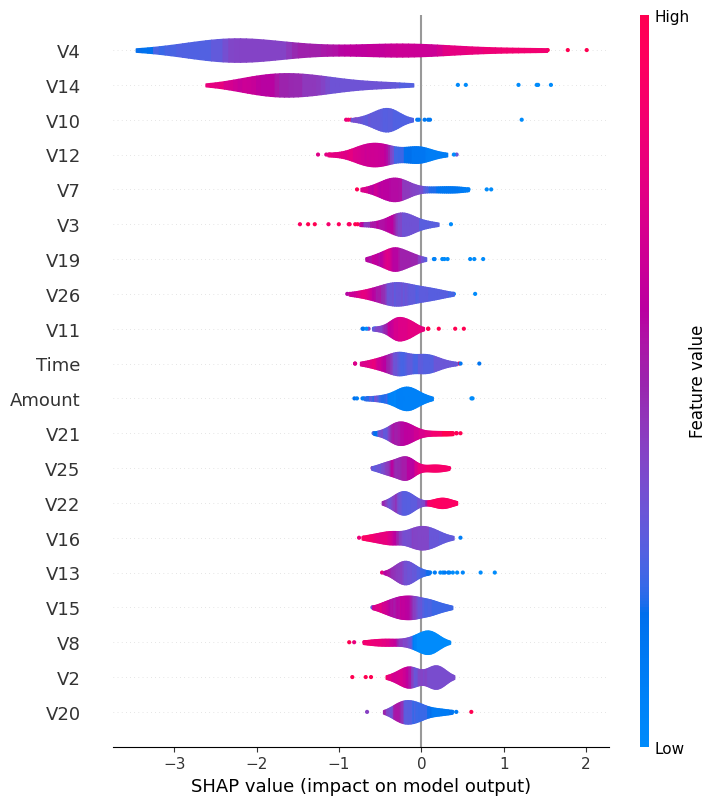

In [25]:
# outro modelo de gráfico em violino, achei interessante pela diferença em espessura e cores representando maiores impactos nessas duas variáveis
import shap
explainer = shap.Explainer(xgb)
shap_values = explainer(x_test[:100])

shap.plots.violin(shap_values)